## EN3160-Fundamentals of Image Processing and Computer Vision
### Assignment 01 - Intensity Transformations and Neighborhood Filtering
**Name:** Bandara H.Y.W. | **Index Number:** 230074J | **GitHub:** https://github.com/YohanBandara/Computer-Vision/tree/main/CV%20assignment1


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Question 1 - Piecewise Linear Intensity Transformation

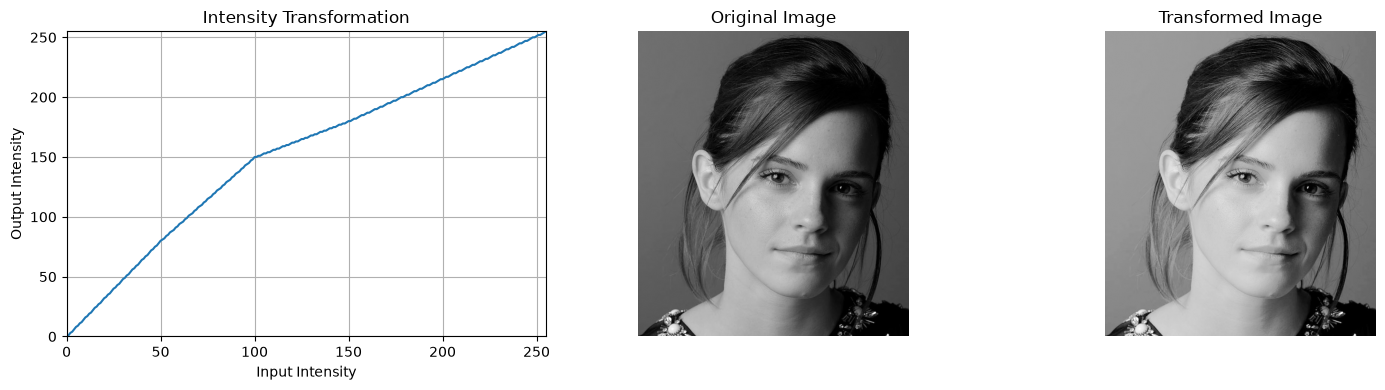

In [101]:
im=cv.imread('images/fig1b_intensity_image.jpg',cv.IMREAD_GRAYSCALE)
assert im is not None,"Image could not be loaded."

def intensity_transform(im,breakpoints):
    bp=np.asarray(breakpoints,dtype=np.float32); x=bp[:,0]; y=bp[:,1]; lut=np.zeros(256,dtype=np.float32)
    for r in range(256):
        if r<=x[0]: lut[r]=y[0]
        elif r>=x[-1]: lut[r]=y[-1]
        else:
            k=np.searchsorted(x,r,side='right')-1; x1=x[k]; y1=y[k]; x2=x[k+1]; y2=y[k+1]
            lut[r]=y1+((r-x1)*(y2-y1)/(x2-x1))
    lut=np.clip(lut,0,255).astype(np.uint8); transformed=cv.LUT(im,lut)
    return transformed,lut

breakpoints=np.array([[0,0],[50,80],[100,150],[150,180],[255,255]])
transformed,lut=intensity_transform(im,breakpoints)

fig,ax=plt.subplots(1,3,figsize=(15,4))
ax[0].plot(np.arange(256),lut); ax[0].set_title('Intensity Transformation'); ax[0].set_xlabel('Input Intensity'); ax[0].set_ylabel('Output Intensity'); ax[0].set_xlim(0,255); ax[0].set_ylim(0,255); ax[0].grid()
ax[1].imshow(im,cmap='gray',vmin=0,vmax=255); ax[1].set_title('Original Image'); ax[1].axis('off')
ax[2].imshow(transformed,cmap='gray',vmin=0,vmax=255); ax[2].set_title('Transformed Image'); ax[2].axis('off')
plt.tight_layout(); plt.show()


### Observation
The piecewise linear transformation changed the contrast by remapping selected intensity ranges. The chosen breakpoints increased the brightness difference between some gray levels, making image details more visible.

### Question 2 - Accentuating White Matter and Gray Matter

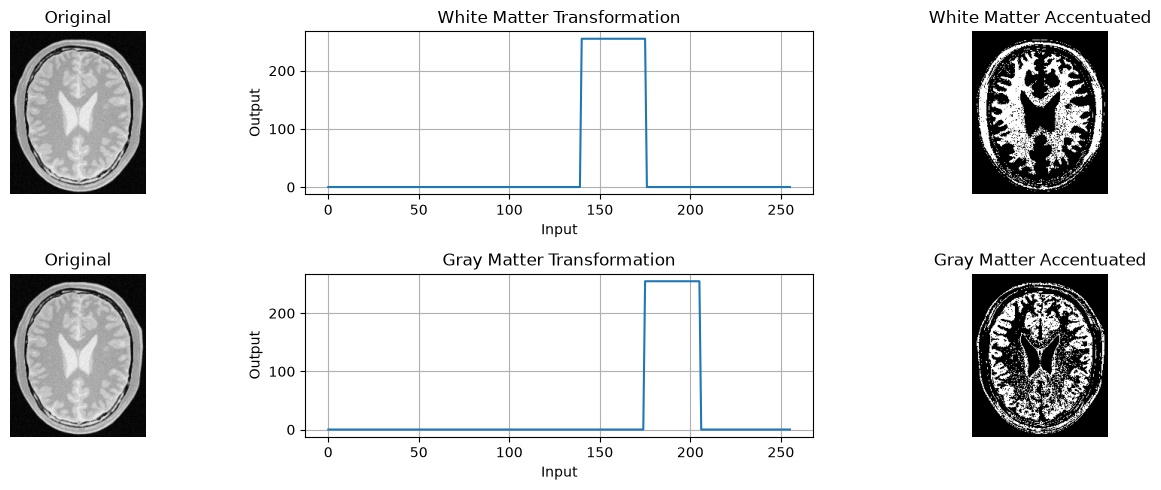

In [102]:
brain=cv.imread('images/fig2_brain_proton_density.png',cv.IMREAD_GRAYSCALE)
assert brain is not None,"Image could not be loaded."

white_bp=np.array([[0,0],[139,0],[140,255],[175,255],[176,0],[255,0]])
gray_bp=np.array([[0,0],[174,0],[175,255],[205,255],[206,0],[255,0]])
white_img,white_lut=intensity_transform(brain,white_bp); gray_img,gray_lut=intensity_transform(brain,gray_bp)

fig,ax=plt.subplots(2,3,figsize=(15,5))
ax[0,0].imshow(brain,cmap='gray',vmin=0,vmax=255); ax[0,0].set_title('Original'); ax[0,0].axis('off')
ax[0,1].plot(np.arange(256),white_lut); ax[0,1].set_title('White Matter Transformation'); ax[0,1].set_xlabel('Input'); ax[0,1].set_ylabel('Output'); ax[0,1].grid()
ax[0,2].imshow(white_img,cmap='gray',vmin=0,vmax=255); ax[0,2].set_title('White Matter Accentuated'); ax[0,2].axis('off')
ax[1,0].imshow(brain,cmap='gray',vmin=0,vmax=255); ax[1,0].set_title('Original'); ax[1,0].axis('off')
ax[1,1].plot(np.arange(256),gray_lut); ax[1,1].set_title('Gray Matter Transformation'); ax[1,1].set_xlabel('Input'); ax[1,1].set_ylabel('Output'); ax[1,1].grid()
ax[1,2].imshow(gray_img,cmap='gray',vmin=0,vmax=255); ax[1,2].set_title('Gray Matter Accentuated'); ax[1,2].axis('off')
plt.tight_layout(); plt.show()

### Observation
Different intensity windows were used to highlight the white matter and gray matter region in brain separately. Pixels inside the selected ranges were mapped to high intensity values while pixels outside the ranges were suppressed.

### Question 3 - Gamma Correction

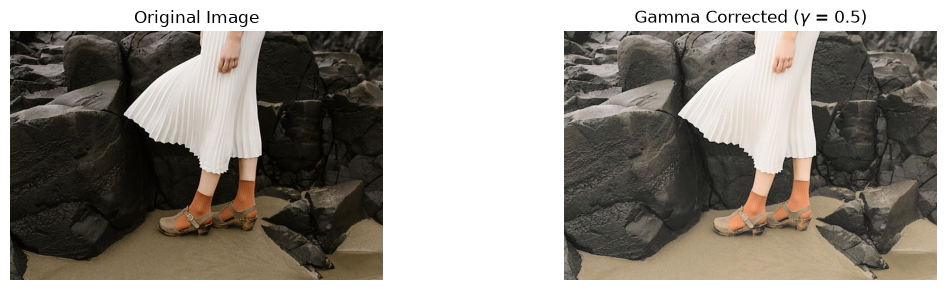

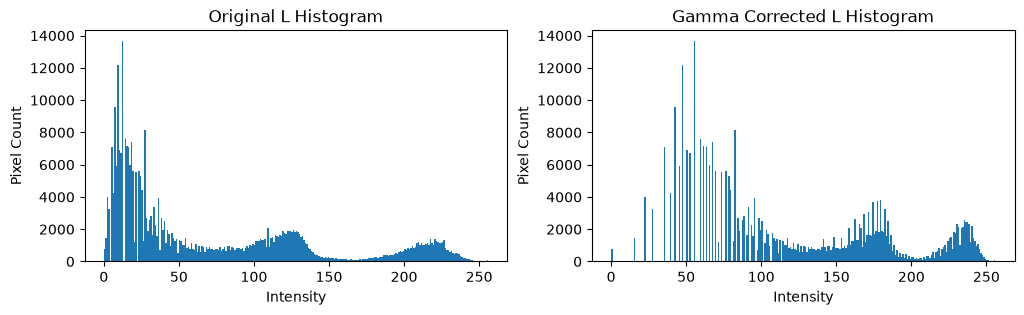

In [104]:
im=cv.imread('images/fig3_gamma_correction.jpg')
assert im is not None,"Image could not be loaded."

lab=cv.cvtColor(im,cv.COLOR_BGR2LAB); L,a,b=cv.split(lab)
gamma=0.5; L_normalized=L.astype(np.float32)/255.0; L_corrected=255*(L_normalized**gamma)
L_corrected=np.clip(L_corrected,0,255).astype(np.uint8)
lab_corrected=cv.merge([L_corrected,a,b]); corrected=cv.cvtColor(lab_corrected,cv.COLOR_LAB2BGR)

fig,ax=plt.subplots(1,2,figsize=(12,3))
ax[0].imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB)); ax[0].set_title('Original Image'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(corrected,cv.COLOR_BGR2RGB)); ax[1].set_title(f'Gamma Corrected ($\\gamma$ = {gamma})'); ax[1].axis('off')
plt.tight_layout(); plt.show()

fig,ax=plt.subplots(1,2,figsize=(12,3))
ax[0].hist(L.ravel(),bins=256,range=(0,256)); ax[0].set_title('Original L Histogram'); ax[0].set_xlabel('Intensity'); ax[0].set_ylabel('Pixel Count')
ax[1].hist(L_corrected.ravel(),bins=256,range=(0,256)); ax[1].set_title('Gamma Corrected L Histogram'); ax[1].set_xlabel('Intensity'); ax[1].set_ylabel('Pixel Count')
plt.show()

### Observation
Gamma correction with \(gamma=0.5\) increased the lightness of the image because \(gamma<1\). The histogram of the L plane shifted toward higher intensity values while the colour information was preserved.

### Question 4 - Vibrance Enhancement

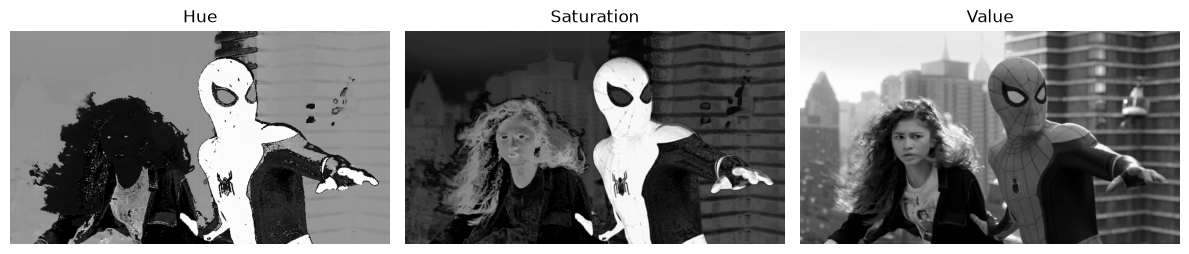

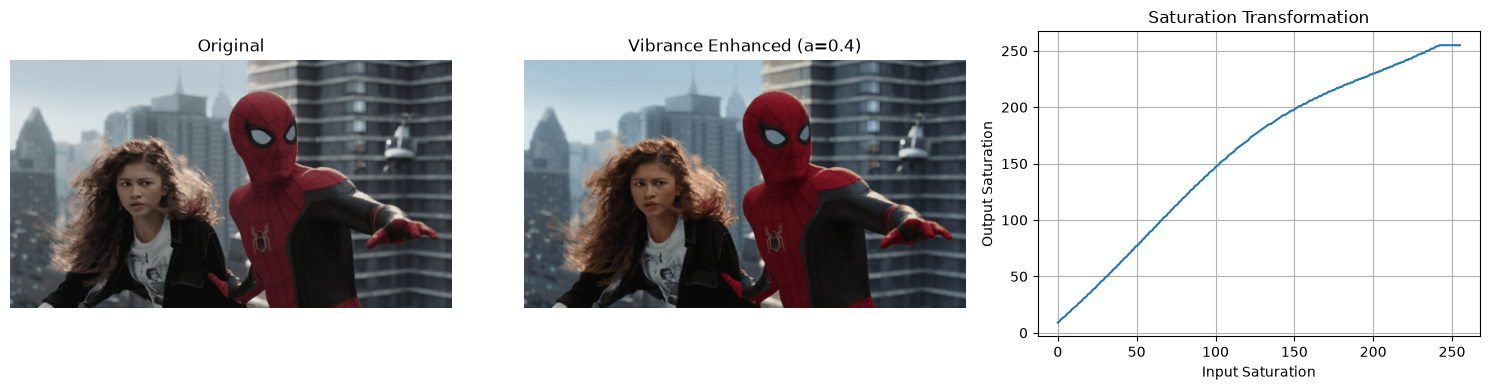

In [105]:
im=cv.imread('images/fig4_vibrance.png')
assert im is not None,"Image could not be loaded."

hsv=cv.cvtColor(im,cv.COLOR_BGR2HSV); H,S,V=cv.split(hsv)
a_value=0.4; sigma=70; x=np.arange(256,dtype=np.float32)
transform=x+a_value*128*np.exp(-((x-128)**2)/(2*sigma**2)); transform=np.minimum(transform,255).astype(np.uint8)
S_new=transform[S]; hsv_new=cv.merge([H,S_new,V]); vibrant=cv.cvtColor(hsv_new,cv.COLOR_HSV2BGR)

fig,ax=plt.subplots(1,3,figsize=(12,4))
ax[0].imshow(H,cmap='gray'); ax[0].set_title('Hue'); ax[0].axis('off')
ax[1].imshow(S,cmap='gray'); ax[1].set_title('Saturation'); ax[1].axis('off')
ax[2].imshow(V,cmap='gray'); ax[2].set_title('Value'); ax[2].axis('off')
plt.tight_layout(); plt.show()

fig,ax=plt.subplots(1,3,figsize=(15,4))
ax[0].imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB)); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(vibrant,cv.COLOR_BGR2RGB)); ax[1].set_title(f'Vibrance Enhanced (a={a_value})'); ax[1].axis('off')
ax[2].plot(x,transform); ax[2].set_title('Saturation Transformation'); ax[2].set_xlabel('Input Saturation'); ax[2].set_ylabel('Output Saturation'); ax[2].grid()
plt.tight_layout(); plt.show()

### Observation
The saturation plane was enhanced using the given nonlinear transformation with \(a=0.4\). The resulting image has stronger and more vivid colours while the hue and brightness remain unchanged.

### Question 5 - Histogram Equalization

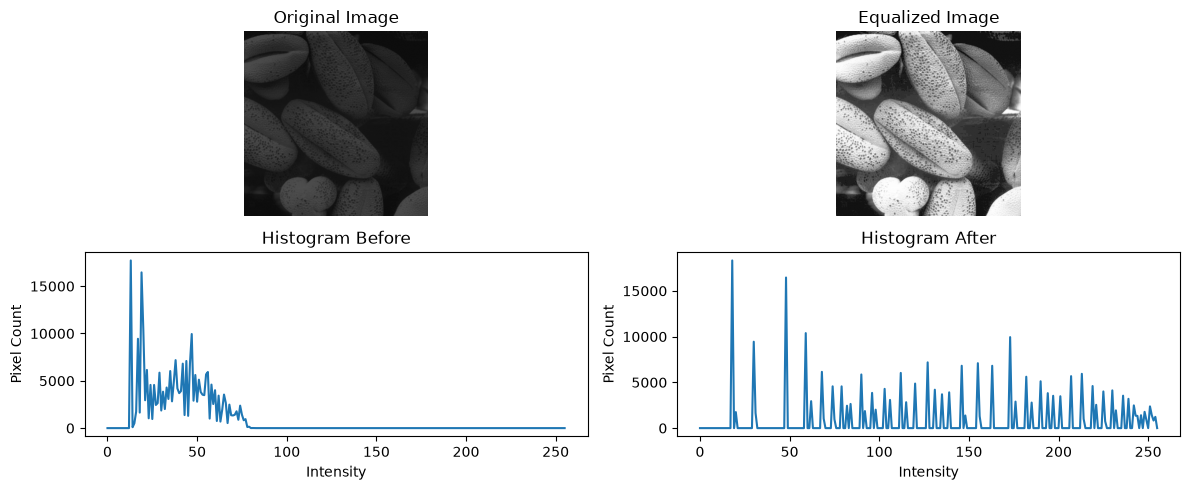

In [106]:
im=cv.imread('images/fig5_histogram_equalization.png',cv.IMREAD_GRAYSCALE)
assert im is not None,"Image could not be loaded."

def my_hist_equalization(im):
    hist=np.bincount(im.ravel(),minlength=256); cdf=np.cumsum(hist); M,N=im.shape
    lut=(255/(M*N)*cdf).astype(np.uint8); result=lut[im]
    return result,hist

equalized,histogram_before=my_hist_equalization(im)
histogram_after=np.bincount(equalized.ravel(),minlength=256)

fig,ax=plt.subplots(2,2,figsize=(12,5))
ax[0,0].imshow(im,cmap='gray',vmin=0,vmax=255); ax[0,0].set_title('Original Image'); ax[0,0].axis('off')
ax[0,1].imshow(equalized,cmap='gray',vmin=0,vmax=255); ax[0,1].set_title('Equalized Image'); ax[0,1].axis('off')
ax[1,0].plot(histogram_before); ax[1,0].set_title('Histogram Before'); ax[1,0].set_xlabel('Intensity'); ax[1,0].set_ylabel('Pixel Count')
ax[1,1].plot(histogram_after); ax[1,1].set_title('Histogram After'); ax[1,1].set_xlabel('Intensity'); ax[1,1].set_ylabel('Pixel Count')
plt.tight_layout(); plt.show()

### Observation
Histogram equalization redistributed the pixel intensities over a wider range. This increased the contrast of the image, and the histogram after equalization became more widely distributed.

### Question 6 - Histogram Equalization of the Foreground

50.0


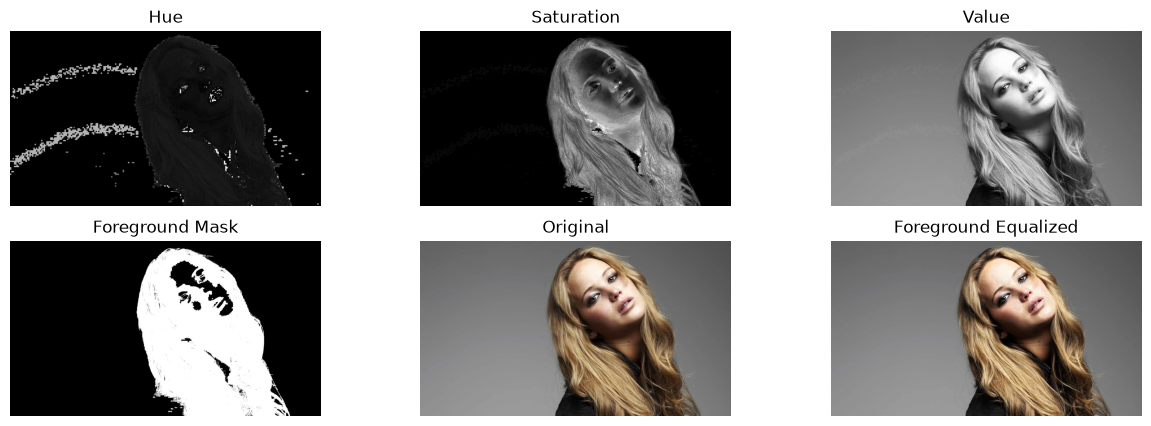

In [107]:
im=cv.imread('images/fig6_foreground_histogram_equalization.jpg')
assert im is not None,"Image could not be loaded."

hsv=cv.cvtColor(im,cv.COLOR_BGR2HSV); H,S,V=cv.split(hsv)
_,mask=cv.threshold(S,50,255,cv.THRESH_BINARY); print(_)
foreground=cv.bitwise_and(im,im,mask=mask); fig_values=V[mask>0]
hist=np.bincount(fig_values,minlength=256); cdf=np.cumsum(hist); N=fig_values.size
lut=(255/N*cdf).astype(np.uint8)

V_new=V.copy(); V_new[mask>0]=lut[V[mask>0]]
hsv_new=cv.merge([H,S,V_new]); equalized=cv.cvtColor(hsv_new,cv.COLOR_HSV2BGR)
eq_foreground=cv.bitwise_and(equalized,equalized,mask=mask)
background=cv.bitwise_and(im,im,mask=cv.bitwise_not(mask)); result=cv.add(eq_foreground,background)

fig,ax=plt.subplots(2,3,figsize=(15,5))
ax[0,0].imshow(H,cmap='gray'); ax[0,0].set_title('Hue'); ax[0,0].axis('off')
ax[0,1].imshow(S,cmap='gray'); ax[0,1].set_title('Saturation'); ax[0,1].axis('off')
ax[0,2].imshow(V,cmap='gray'); ax[0,2].set_title('Value'); ax[0,2].axis('off')
ax[1,0].imshow(mask,cmap='gray'); ax[1,0].set_title('Foreground Mask'); ax[1,0].axis('off')
ax[1,1].imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB)); ax[1,1].set_title('Original'); ax[1,1].axis('off')
ax[1,2].imshow(cv.cvtColor(result,cv.COLOR_BGR2RGB)); ax[1,2].set_title('Foreground Equalized'); ax[1,2].axis('off')
plt.show()

### Observation
A threshold on the saturation plane was used to obtain the foreground mask. Histogram equalization was applied only to the foreground, improving its contrast while keeping the background unchanged.

### Question 7 - Sobel Filtering

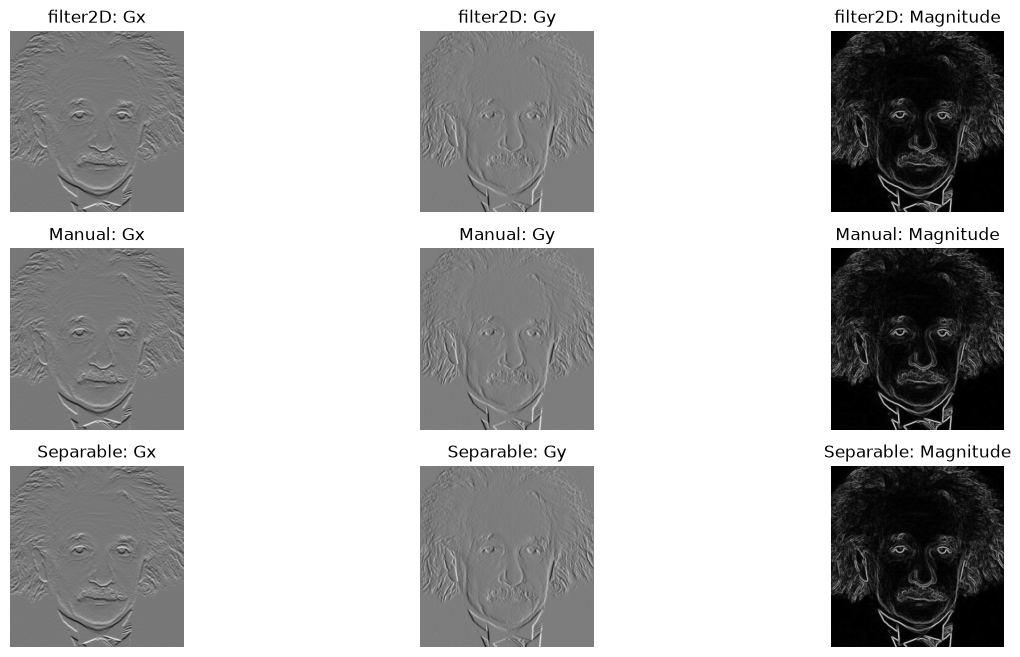

In [109]:
im=cv.imread('images/fig7_sobel_filtering.png',cv.IMREAD_GRAYSCALE)
assert im is not None,"Image could not be loaded."

sobel_x=np.array([[1,2,1],[0,0,0],[-1,-2,-1]],dtype=np.float64)
sobel_y=np.array([[1,0,-1],[2,0,-2],[1,0,-1]],dtype=np.float64)

Gx=cv.filter2D(im,cv.CV_64F,sobel_x); Gy=cv.filter2D(im,cv.CV_64F,sobel_y); mag=np.sqrt(Gx**2+Gy**2)

def sob_filter2D(im,kernel):
    h,w=im.shape; kh,kw=kernel.shape; ph,pw=kh//2,kw//2
    padded=np.pad(im.astype(np.float64),((ph,ph),(pw,pw)),mode='reflect'); out=np.zeros((h,w),dtype=np.float64)
    for x in range(h):
        for y in range(w):
            region=padded[x:x+kh,y:y+kw]; out[x,y]=np.sum(region*kernel)
    return out

Gx_manual=sob_filter2D(im,sobel_x); Gy_manual=sob_filter2D(im,sobel_y); mag_manual=np.sqrt(Gx_manual**2+Gy_manual**2)
smooth=np.array([1,2,1],dtype=np.float64); derivative=np.array([1,0,-1],dtype=np.float64)
Gx_sep=cv.sepFilter2D(im,cv.CV_64F,smooth,derivative); Gy_sep=cv.sepFilter2D(im,cv.CV_64F,derivative,smooth); mag_sep=np.sqrt(Gx_sep**2+Gy_sep**2)

fig,ax=plt.subplots(3,3,figsize=(15,8))
ax[0,0].imshow(Gx,cmap='gray'); ax[0,0].set_title('filter2D: Gx')
ax[0,1].imshow(Gy,cmap='gray'); ax[0,1].set_title('filter2D: Gy')
ax[0,2].imshow(mag,cmap='gray'); ax[0,2].set_title('filter2D: Magnitude')
ax[1,0].imshow(Gx_manual,cmap='gray'); ax[1,0].set_title('Manual: Gx')
ax[1,1].imshow(Gy_manual,cmap='gray'); ax[1,1].set_title('Manual: Gy')
ax[1,2].imshow(mag_manual,cmap='gray'); ax[1,2].set_title('Manual: Magnitude')
ax[2,0].imshow(Gx_sep,cmap='gray'); ax[2,0].set_title('Separable: Gx')
ax[2,1].imshow(Gy_sep,cmap='gray'); ax[2,1].set_title('Separable: Gy')
ax[2,2].imshow(mag_sep,cmap='gray'); ax[2,2].set_title('Separable: Magnitude')
for a in ax.ravel(): a.axis('off')
plt.show()

### Observation
The Sobel operator detected intensity changes in the \(x\) and \(y\) directions, and the gradient magnitude showed the overall edge strength. The OpenCV, manual, and separable implementations produced similar edge responses.

### Question 8 - Image Zooming

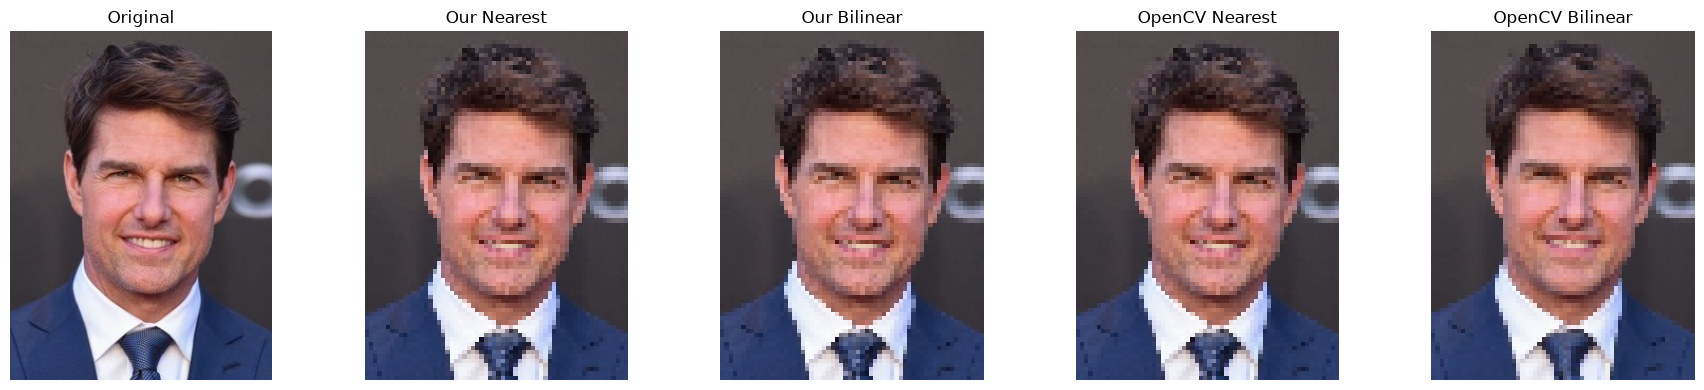

In [95]:
def nearest_zoom(im,scale):
    h,w=im.shape[:2]; new_h,new_w=int(h*scale),int(w*scale); out=np.zeros((new_h,new_w,3),dtype=np.uint8)
    for x in range(new_h):
        for y in range(new_w):
            src_x=min(int(x/scale),h-1); src_y=min(int(y/scale),w-1); out[x,y]=im[src_x,src_y]
    return out

def bilinear_zoom(im,scale):
    h,w=im.shape[:2]; new_h,new_w=int(h*scale),int(w*scale); out=np.zeros((new_h,new_w,3),dtype=np.uint8)
    for x in range(new_h):
        for y in range(new_w):
            src_x,src_y=x/scale,y/scale; x1,y1=int(np.floor(src_x)),int(np.floor(src_y))
            x2,y2=min(x1+1,h-1),min(y1+1,w-1); dx,dy=src_x-x1,src_y-y1
            out[x,y]=(1-dx)*(1-dy)*im[x1,y1]+dx*(1-dy)*im[x2,y1]+(1-dx)*dy*im[x1,y2]+dx*dy*im[x2,y2]
    return out

image_names=['tom.jpg']; scale=1/4

for name in image_names:
    im=cv.imread('images/'+name); assert im is not None,f"{name} could not be loaded."
    nearest=nearest_zoom(im,scale); bilinear=bilinear_zoom(im,scale)
    cv_nearest=cv.resize(im,None,fx=scale,fy=scale,interpolation=cv.INTER_NEAREST)
    cv_bilinear=cv.resize(im,None,fx=scale,fy=scale,interpolation=cv.INTER_LINEAR)
    fig,ax=plt.subplots(1,5,figsize=(18,4)); imgs=[im,nearest,bilinear,cv_nearest,cv_bilinear]; titles=['Original','Our Nearest','Our Bilinear','OpenCV Nearest','OpenCV Bilinear']
    for i in range(5): ax[i].imshow(cv.cvtColor(imgs[i],cv.COLOR_BGR2RGB)); ax[i].set_title(titles[i]); ax[i].axis('off')
    plt.tight_layout(); plt.show()

### Observation
Nearest neighbor interpolation produced sharper but more blocky results, while bilinear interpolation produced smoother results by using the four surrounding pixels. The manually implemented methods produced results visually similar to the corresponding OpenCV interpolation methods.
I have used a photo of Tom Cruse actor since there wasn't any images provided for this queston.

### Question 9 - Foreground Segmentation and Background Blurring

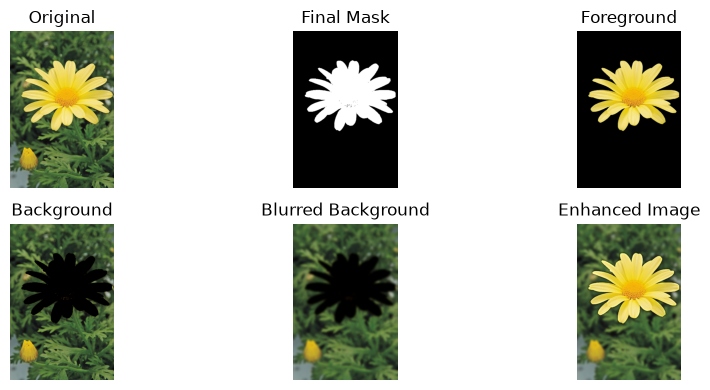

In [112]:
im=cv.imread('images/fig8_grabcut_flower.jpg')
assert im is not None,"Image could not be loaded."

h,w=im.shape[:2]; mask=np.zeros((h,w),np.uint8)
bg_model=np.zeros((1,65),np.float64); fg_model=np.zeros((1,65),np.float64)
rect=(0,0,550,600)

cv.grabCut(im,mask,rect,bg_model,fg_model,5,cv.GC_INIT_WITH_RECT)
mask_binary=np.where((mask==cv.GC_FGD)|(mask==cv.GC_PR_FGD),255,0).astype(np.uint8)
foreground=cv.bitwise_and(im,im,mask=mask_binary)
background=cv.bitwise_and(im,im,mask=cv.bitwise_not(mask_binary))
blurred_background=cv.GaussianBlur(background,(31,31),0); enhanced=cv.add(foreground,blurred_background)

fig,ax=plt.subplots(2,3,figsize=(10,4))
ax[0,0].imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB)); ax[0,0].set_title('Original'); ax[0,0].axis('off')
ax[0,1].imshow(mask_binary,cmap='gray'); ax[0,1].set_title('Final Mask'); ax[0,1].axis('off')
ax[0,2].imshow(cv.cvtColor(foreground,cv.COLOR_BGR2RGB)); ax[0,2].set_title('Foreground'); ax[0,2].axis('off')
ax[1,0].imshow(cv.cvtColor(background,cv.COLOR_BGR2RGB)); ax[1,0].set_title('Background'); ax[1,0].axis('off')
ax[1,1].imshow(cv.cvtColor(blurred_background,cv.COLOR_BGR2RGB)); ax[1,1].set_title('Blurred Background'); ax[1,1].axis('off')
ax[1,2].imshow(cv.cvtColor(enhanced,cv.COLOR_BGR2RGB)); ax[1,2].set_title('Enhanced Image'); ax[1,2].axis('off')
plt.tight_layout(); plt.show()

### c) Observation
A dark edge can appear near the flower boundary when the extracted background is blurred because the removed foreground region contains black pixels. Gaussian filtering averages these black pixels with nearby background pixels, producing darker values near the boundary.

### Question 10 - Bilateral Filtering

MSE between OpenCV and manual: 18.788497999384425


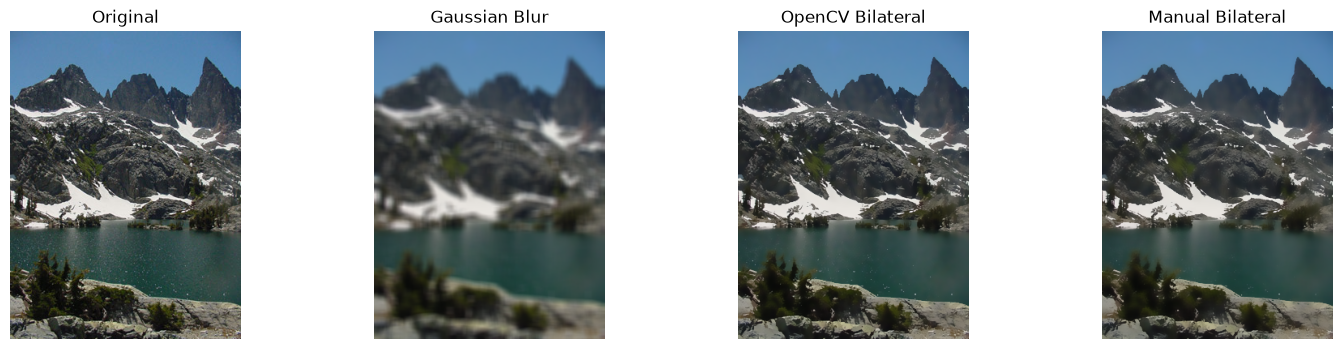

In [113]:
im=cv.imread('images/fig9_bilateral_filtering.jpg')
assert im is not None,"Image could not be loaded."

d=9; sigma_s=20; sigma_r=50
gaussian=cv.GaussianBlur(im,(9,9),sigma_s)
bilateral_cv=cv.bilateralFilter(im,d,sigma_r,sigma_s)

def bilateral(im,d,sigma_s,sigma_r):
    r=d//2; h,w=im.shape[:2]
    padded=cv.copyMakeBorder(im,r,r,r,r,cv.BORDER_REFLECT); out=np.zeros_like(im,dtype=np.float64)
    for x in range(h):
        for y in range(w):
            center=padded[x+r,y+r].astype(np.float64); region=padded[x:x+d,y:y+d].astype(np.float64)
            result=np.zeros(3); weights=np.zeros((d,d))
            for i in range(d):
                for j in range(d):
                    spatial=np.exp(-((i-r)**2+(j-r)**2)/(2*sigma_s**2))
                    diff=np.linalg.norm(region[i,j]-center); intensity=np.exp(-(diff**2)/(2*sigma_r**2))
                    weights[i,j]=spatial*intensity; result+=weights[i,j]*region[i,j]
            out[x,y]=result/np.sum(weights)
    return np.clip(out,0,255).astype(np.uint8)

bilateral_manual=bilateral(im,d,sigma_s,sigma_r)
mse=np.mean((bilateral_cv.astype(np.float64)-bilateral_manual.astype(np.float64))**2)
print("MSE between OpenCV and manual:",mse)

fig,ax=plt.subplots(1,4,figsize=(18,4))
images=[im,gaussian,bilateral_cv,bilateral_manual]; titles=['Original','Gaussian Blur','OpenCV Bilateral','Manual Bilateral']
for i in range(4): ax[i].imshow(cv.cvtColor(images[i],cv.COLOR_BGR2RGB)); ax[i].set_title(titles[i]); ax[i].axis('off')
plt.show()

### Observation
Gaussian filtering smoothed the image but also blurred strong edges, while bilateral filtering preserved the edges better by considering both spatial distance and colour similarity. The low MSE between the manual and OpenCV bilateral results indicates that the two implementations produced similar outputs.